# Position Matters: Statistical Profiles Across the PLL - Team Analysis
## Data Pre-Processing and Cleaning

The next analytical goal focuses on each team in the PLL. We want to determine which player statistics have the greatest impact on winning games. First, we must update and clean the data. 
<br><br>
We need to create team-level statistics to compare. The PLL has a team-level dataset available, but we want to utilize the same dataset in order to extend the previous analysis. We utilize the PLL's team dataset to ensure our calculations are within reasonable error.

In [1]:
#import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scipy
import scipy
import scipy.stats as stats
import matplotlib.ticker as mtick

### Import the original unclean player dataset

In [2]:
#Import the dataset
dataset = pd.read_csv("pll-player-stats.csv")
player_stats_data = dataset.copy()

## Calculate team statistics from player data

Aggregate the data within a team. Use the sum function to find the total number of goals, points, saves, etc.

In [3]:
#determine team stats from player data
team_stats_from_players = player_stats_data.groupby("Team").agg({
    "Points": "sum",
    "Total Goals":"sum",
    "1Pt Goals":"sum",
    "2Pt Goals":"sum",
    "Assists":"sum",
    "Shots": "sum",
    "2Pt Shots" :"sum", 
    "Shots On Goal": "sum", 
    "2Pt Shots On Goal":"sum",
    "Groundballs":"sum",
    "Turnovers":"sum",
    "Caused Turnovers":"sum",
    "Faceoffs Won":"sum",
    "Faceoffs Lost":"sum",
    "Faceoffs": "sum",
    "Saves":"sum",
    "Clean Saves":"sum",
    "Scores Against":"sum",
    "Penalties":"sum",
    "Penalties (in minutes)":"sum",
    "2Pt Goals Against":"sum",
    "Power Play Goals":"sum",
    "Power Play Shots":"sum",
    "Power Play Goals Against":'sum',
    "Passes":'sum'}).reset_index()

#rename columns to avoid confusion with player stats
team_stats_from_players=team_stats_from_players.rename(columns={
    "Points": "Team Points",
    "Total Goals": "Team Total Goals",
    "1Pt Goals":"Team One Point Goals",
    "2Pt Goals": "Team Two Point Goals",
    "Assists":"Team Assists",
    "Shots":"Team Shots",
    "2Pt Shots": "Team Two Points Shots",
    "Shots On Goal":"Team SOG",
    "2Pt Shots On Goal":"Team Two Point SOG",
    "Groundballs":"Team Groundballs",
    "Turnovers":"Team Turnovers",
    "Caused Turnovers":"Team Caused Turnovers",
    "Faceoffs Won":"Team Faceoffs Won",
    "Faceoffs Lost":"Team Faceoffs Lost",
    "Faceoffs":"Team Total Faceoffs",
    "Saves":"Team Saves",
    "Clean Saves":"Team Clean Saves",
    "Scores Against":"Team Scores Against",
    "Penalties":"Team Penalties",
    "Penalties (in minutes)":"Team PIM",
    "2Pt Goals Against":"Team Two Point Goals Against",
    "Power Play Goals":"Team Power Play Goals",
    "Power Play Shots":"Team Power Play Shots",
    "Power Play Goals Against":"Team Power Play Goals Against",
    "Passes":"Team Passes"})

### Calculate percentages for each team manually

In [4]:
#calculate the percentages for the team
team_stats_from_players["Team Shot Pct"] = team_stats_from_players["Team Total Goals"]/team_stats_from_players["Team Shots"]

team_stats_from_players["Team SOG Pct"] = team_stats_from_players["Team SOG"]/team_stats_from_players["Team Shots"]

team_stats_from_players["Team Faceoff Pct"] = team_stats_from_players["Team Faceoffs Won"]/team_stats_from_players["Team Total Faceoffs"]

team_stats_from_players["Team Save Pct"]=team_stats_from_players["Team Saves"]/(team_stats_from_players["Team Saves"]+team_stats_from_players["Team Scores Against"]-team_stats_from_players["Team Two Point Goals Against"])

team_stats_from_players["Team Clean Save Pct"]=team_stats_from_players["Team Clean Saves"]/team_stats_from_players["Team Saves"]

### Compare the team-level statistics to the PLL official team statistics

In [5]:
#read official PLL team stats file
pll_official_team_stats = pd.read_csv("pll-team-stats.csv")

#compare the statistics by looking at error between values

#define the statistics pairs between datasets
the_pairs = {
    "Team Total Goals":"Goals",
    "Team One Point Goals": "One Point Goals",
    "Team Two Point Goals":"Two Point Goals",
    "Team Assists":"Assists",
    "Team Shots":"Shots",
    "Team Two Points Shots":"Two Point Shots",
    "Team SOG":"SOG", 
    "Team Two Point SOG": "Two Point SOG", 
    "Team Groundballs":"Groundballs",
    "Team Turnovers":"Turnovers",
    "Team Caused Turnovers":"Caused Turnovers",
    "Team Faceoffs Won":"Faceoffs Won",
    "Team Faceoffs Lost":"Faceoffs Lost",
    "Team Saves":"Saves",
    "Team Penalties":"Penalties",
    "Team PIM":"PIM",
    "Team Two Point Goals Against":"Two Point Goals Against",
    "Team Power Play Goals":"Power Play Goals",
    "Team Power Play Shots":"Power Play Shots",
    "Team Passes":"Passes",
    "Team Shot Pct":"Shot Pct",
    "Team SOG Pct":"SOG Pct",
    "Team Faceoff Pct":"Faceoff Pct",
    "Team Save Pct":"Save Pct"}

#merge the datasets for comparison
merged_stats = team_stats_from_players.merge(pll_official_team_stats, on="Team", suffixes = ("_test", "_official"))

#define error summary
stat_error_summary=[]

for test_col, official_col in the_pairs.items():
    abs_error = (merged_stats[test_col]-merged_stats[official_col]).abs()
    pct_error = (abs_error/merged_stats[official_col]).abs()*100

    stat_error_summary.append({
        "Statistic":test_col,
        "Mean Absolute Error": abs_error.mean(),
        "Max Absolute Error":abs_error.max(),
        "Mean Percent Error":pct_error.mean(),
        "Max Percent Error":pct_error.max()})

#make it a dataframe for visualization
error_df=pd.DataFrame(stat_error_summary)

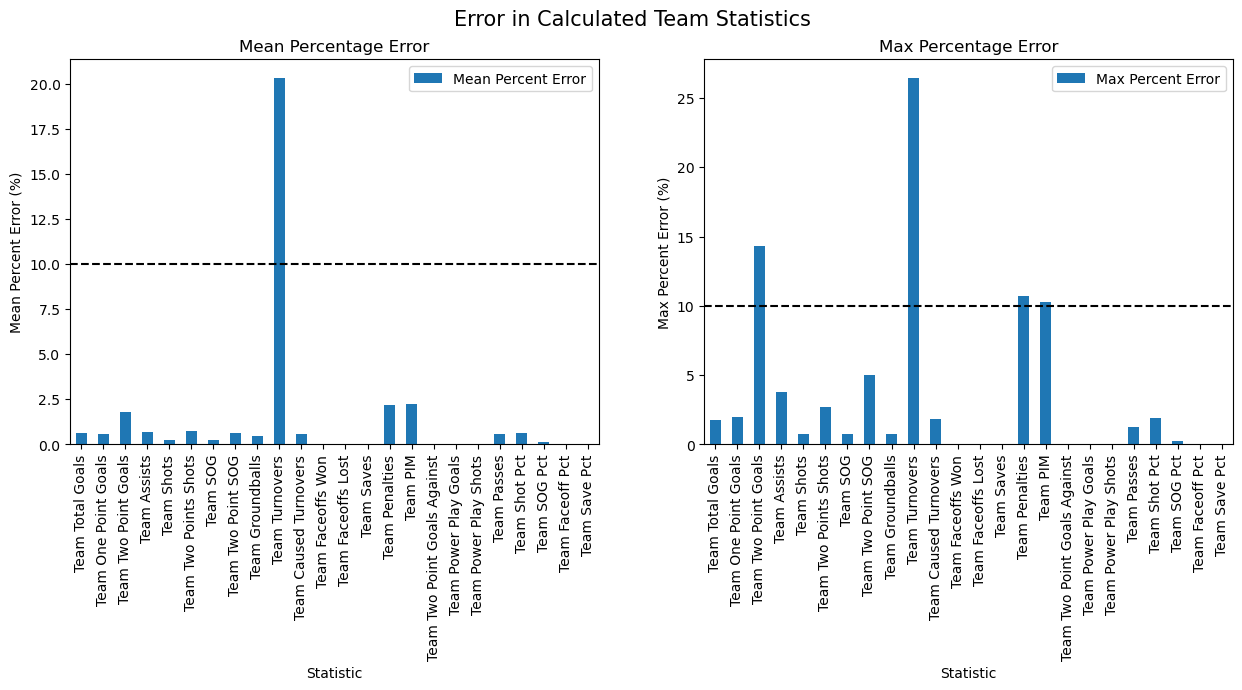

In [6]:
#visualize the error
fig_a, axes_a=plt.subplots(1,2,figsize=(15,5))
fig_a.suptitle("Error in Calculated Team Statistics",fontsize=15)
error_df.plot.bar(x="Statistic", y="Mean Percent Error", ax=axes_a[0])
axes_a[0].set_ylabel("Mean Percent Error (%)")
axes_a[0].set_title("Mean Percentage Error")
axes_a[0].axhline(y=10, color='k', linestyle='--')

error_df.plot.bar(x="Statistic", y="Max Percent Error", ax=axes_a[1])
axes_a[1].set_ylabel("Max Percent Error (%)")
axes_a[1].set_title("Max Percentage Error")
axes_a[1].axhline(y=10,color='k', linestyle='--')

**Analysis**<br>
The Team Turnovers statistic is the greatest for both mean and max percentage error. Hence, we will not be using it in our team statistic's importance to wins feature analysis. The mean percentage error for each of the other statistics is below 5.0%. This is ideal for analysis. The maximum percent error is above 10% for Turnovers, Two Point Goals, Penalties, and Penalties in Minutes. We will be excluding these statistics from the feature importance analysis as well.

## Add win-lose records for each team
These statistics are available on the PLL website (https://premierlacrosseleague.com/standings). However, it must be manually transcribed due to a lack of downloadable file.

In [7]:
#online statistics as their own dataframe
team_win_lose_records=pd.DataFrame({
    "Team":["Atlas", "Whipsnakes","Waterdogs", "Cannons", "Outlaws", "Redwoods", "Chaos", "Archers"],
    "Game Wins":[7,4,4,4,7,5,5,4],
    "Game Losses":[3,6,6,6,3,5,5,6],
    "Scores":[137,119,124,127,131,126,110,98],
    "Scores Against":[120,108,127,138,113,130,125,111],
    "Score Differential":[17,11,-3,-11,18,-4,-15,-13]})

In [8]:
#merge the wins/losses data with original dataframe
team_stats_from_players=team_stats_from_players.merge(team_win_lose_records,on="Team")

#double check the stats made it into the dataframe
team_stats_from_players[["Team","Team Faceoff Pct","Game Wins", "Game Losses"]]

,Team,Team Faceoff Pct,Game Wins,Game Losses
0,Archers,0.316017,4,6
1,Atlas,0.562278,7,3
2,Cannons,0.422535,4,6
3,Chaos,0.501946,5,5
4,Outlaws,0.507634,7,3
5,Redwoods,0.568841,5,5
6,Waterdogs,0.492537,4,6
7,Whipsnakes,0.572549,4,6


## Clean the Dataset
We note that merging the datasets helped do a little bit of data cleaning as well.

### Check for null values

In [9]:
team_stats_from_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Team                           8 non-null      object 
 1   Team Points                    8 non-null      int64  
 2   Team Total Goals               8 non-null      int64  
 3   Team One Point Goals           8 non-null      int64  
 4   Team Two Point Goals           8 non-null      int64  
 5   Team Assists                   8 non-null      int64  
 6   Team Shots                     8 non-null      int64  
 7   Team Two Points Shots          8 non-null      int64  
 8   Team SOG                       8 non-null      int64  
 9   Team Two Point SOG             8 non-null      int64  
 10  Team Groundballs               8 non-null      int64  
 11  Team Turnovers                 8 non-null      int64  
 12  Team Caused Turnovers          8 non-null      int64  

There are no statistics with null values.

In [10]:
team_stats_from_players_clean=team_stats_from_players.copy()

### Check for duplicates

In [11]:
#Check if there are duplicated rows
print("Duplicated rows:", team_stats_from_players_clean.duplicated().sum())

Duplicated rows: 0


There are no duplicate rows, which is good. We can continue with cleaning.

### Sanity Check Percentage Columns

In [12]:
#list columns that are percentage values
percent_columns = ["Team Shot Pct", "Team SOG Pct", "Team Faceoff Pct", "Team Save Pct", "Team Clean Save Pct"]
pct_col = team_stats_from_players_clean[percent_columns]

for col in pct_col:
    print(col, ":", team_stats_from_players_clean[col].min(), team_stats_from_players_clean[col].max())

Team Shot Pct : 0.25 0.30210772833723654
Team SOG Pct : 0.616504854368932 0.6587677725118484
Team Faceoff Pct : 0.31601731601731603 0.5725490196078431
Team Save Pct : 0.49583333333333335 0.5910931174089069
Team Clean Save Pct : 0.3150684931506849 0.5511811023622047


All these values are between 0 and 1, which is expected. We can continue.

### Export new cleaned dataset to csv
Now that the new dataset is created and cleaned, we can export it to a new file to use for the analysis.

In [13]:
team_stats_from_players_clean.to_csv("pll-team-from-player-stats-clean.csv", index = False)